# Imports

In [1]:
from train.test import GANTester
import math
import torch, os
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from skimage.transform import resize, rescale
from scipy.ndimage import rotate
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
malignant_nodules = '/data/Datasets/Lungs/LUNA25-NLST/2D_patches_malign/'
benign_nodules = '/data/Datasets/Lungs/LUNA25-NLST/2D_patches_benign/'
malignant_folders = np.array([os.path.join(malignant_nodules, folder) for folder in np.sort(os.listdir(malignant_nodules))])[:91]
benign_folders = np.array([os.path.join(benign_nodules, folder) for folder in np.sort(os.listdir(benign_nodules))])[:91]
malignant_label = np.array([1 for _ in range(len(malignant_folders))])
benign_label = np.array([0 for _ in range(len(benign_folders))])

#Dataframe with patient_id, malignant/benign label and path
malignant_df = pd.DataFrame(malignant_folders, columns=['folder'])
malignant_df['patient_id'] = np.sort(os.listdir(malignant_nodules))[:91]
malignant_df['patient_id'] = malignant_df['patient_id'].astype(int)
malignant_df['malignancy'] = malignant_label


benign_df = pd.DataFrame(benign_folders, columns=['folder'])
benign_df['patient_id'] = np.sort(os.listdir(benign_nodules))[:91]
benign_df['patient_id'] = benign_df['patient_id'].astype(int)
benign_df['malignancy'] = benign_label

nlst_df = pd.concat([malignant_df, benign_df], ignore_index=True)

chile_dataset = '/data/arumota/Nodules_Ohif/patch_chile/'
path_folders = [os.path.join(chile_dataset, patient) for patient in sorted(os.listdir(chile_dataset))]

chile_df = pd.read_csv('/data/arumota/PhD/Automation_bias/chile_malignancy.csv', sep=';')
chile_df.rename(columns={'class': 'malignancy', 'patient': 'patient_id'}, inplace=True)
chile_df['patient_id'] = chile_df['patient_id'].astype(int)

#Add the paths on the dataframe
chile_df['folder'] = path_folders

df_nlst_chile_merge = nlst_df.merge(chile_df, on=['patient_id'], how='outer')
df_nlst_chile_merge.rename(columns={'folder_y': 'folder', 'malignancy_y': 'malignancy'}, inplace=True)

# Merge folder_x and folder if folder_x is NaN
df_nlst_chile_merge['folder'] = df_nlst_chile_merge['folder'].combine_first(df_nlst_chile_merge['folder_x'])
df_nlst_chile_merge['malignancy'] = df_nlst_chile_merge['malignancy'].combine_first(df_nlst_chile_merge['malignancy_x'])
del df_nlst_chile_merge['folder_x']; del df_nlst_chile_merge['malignancy_x']

df = pd.concat([df_nlst_chile_merge, nlst_df], ignore_index=True)
df = df.drop_duplicates(subset=['patient_id'], keep='first')
df

,patient_id,malignancy,folder
0,100004,0.0,/data/arumota/Nodules_Ohif/patch_chile/100004
1,100005,0.0,/data/arumota/Nodules_Ohif/patch_chile/100005
2,100012,1.0,/data/Datasets/Lungs/LUNA25-NLST/2D_patches_ma...
3,100019,0.0,/data/arumota/Nodules_Ohif/patch_chile/100019
4,100026,0.0,/data/arumota/Nodules_Ohif/patch_chile/100026
...,...,...,...
251,117777,1.0,/data/Datasets/Lungs/LUNA25-NLST/2D_patches_ma...
252,117799,1.0,/data/Datasets/Lungs/LUNA25-NLST/2D_patches_ma...
253,117950,1.0,/data/Datasets/Lungs/LUNA25-NLST/2D_patches_ma...
254,117966,1.0,/data/Datasets/Lungs/LUNA25-NLST/2D_patches_ma...


In [3]:
chile_df.groupby('malignancy').count()

,patient_id,folder
malignancy,,
0,49,49
1,39,39


In [5]:
df.groupby('malignancy').count()

,patient_id,folder
malignancy,,
0.0,139,139
1.0,117,117


In [7]:
os.listdir('/data/Datasets/Lungs/LUNA25-NLST/')

['2D_patches_benign',
 'series-data1743625009234_1.csv',
 'metadata_1.csv',
 'series-data1743694611985_3.csv',
 'metadata_6.csv',
 'NLST_2D_patches',
 'series-data1743691494889_2.csv',
 'Dataset',
 '2D_patches_malign',
 'series-data1745781426912.csv',
 'Patient_DICOM_benign_V3',
 'series-data1745768097118.csv',
 's12911-024-02820-9.pdf',
 'Patient_REC_benign',
 'metadata_5.csv',
 'metadata_2.csv',
 'manifest-1746414076365.tcia',
 'manifest-1746414076365',
 'Patient_DICOM_malign_V3',
 'metadata_3.csv',
 'metadata_4.csv',
 'Patient_REC_malign',
 'series-data1743695547431_4.csv']

In [9]:
import random
malignant_nodules = '/data/Datasets/Lungs/LUNA25-NLST/Patient_DICOM_malign_V3/'
benign_nodules = '/data/Datasets/Lungs/LUNA25-NLST/Patient_DICOM_benign_V3/'

# list
list_malignant = os.listdir(malignant_nodules)
list_benign = os.listdir(benign_nodules)

print(f'malignant_nodules are: {len(list_malignant)}')
print(f'benign_nodules are: {len(list_benign)}')

label_malignant = np.ones(len(list_malignant))
label_benign = np.zeros(len(list_benign))

# Concatenate and random
nodules_complete = np.concatenate((list_malignant, list_benign))
labels_complete = np.concatenate((label_malignant, label_benign))
# Create a seed
np.random.seed(42)
rng = np.random.default_rng(seed=42)
# Shuffle the nodules_complete array
nodules_random = rng.permutation(nodules_complete)
labels_random = rng.permutation(labels_complete)
print(nodules_random)
print(labels_random)

malignant_nodules are: 196
benign_nodules are: 191
['105929_LLL(6)_S(109)_Y(0)' '212359_RUL(1)_S(53)_Y(0)'
 '134493_RUL(1)_S(44)_Y(0)'
 '104822_Unknown(-1)_S(35)-Unknown(-1)_S(68)-Unknown(-1)_S(67)-Unknown(-1)_S(73)-Unknown(-1)_S(75)_Y(0)'
 '214572_RUL(1)_S(44)_Y(0)' '111428_Lin(5)_S(67)-Lin(5)_S(87)_Y(0)'
 '101706_RML(2)_S(44)_Y(0)' '119433_RLL(3)_S(99)_Y(0)'
 '133934_RUL(1)_S(24)_Y(0)' '117966_Unknown(-1)_S(38)_Y(1)'
 '106926_RUL(1)_S(21)_Y(0)' '213972_RUL(1)_S(38)_Y(2)'
 '117502_Unknown(-1)_S(34)_Y(2)' '123247_Unknown(-1)_S(53)_Y(1)'
 '102661_RML(2)_S(80)-RML(2)_S(83)_Y(0)' '107118_LUL(4)_S(54)_Y(0)'
 '117699_RLL(3)_S(59)_Y(0)' '212863_Unknown(-1)_S(133)_Y(2)'
 '120632_LLL(6)_S(122)_Y(0)' '105367_RUL(1)_S(48)_Y(1)'
 '129285_RUL(1)_S(25)_Y(0)' '218035_RLL(3)_S(79)_Y(1)'
 '107811_RLL(3)_S(82)_Y(0)'
 '106574_LLL(6)_S(133)-LLL(6)_S(129)-LLL(6)_S(118)-LLL(6)_S(122)-LLL(6)_S(125)_Y(0)'
 '110621_RUL(1)_S(30)-RUL(1)_S(67)_Y(0)' '117454_Lin(5)_S(70)_Y(0)'
 '126698_RUL(1)_S(87)-RUL(1)_S(51)_Y

# Loading Data

In [2]:
from config.options import Options
opt = Options().parse()

from data.data import NLSTDatasetV1
print(f'The folder path is {opt.folder_path}')
dataset = NLSTDatasetV1(opt.folder_path) 

# Access the datasets using indexing
train_dataset = dataset['train']  # Get train dataset
test_dataset = dataset['test']    # Get test dataset
print(f'Train dataset size: {len(train_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

# Pass the dataset to DataLoader
train_loader = DataLoader(train_dataset, batch_size=opt.batchsize, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=opt.batchsize, shuffle=False)

2025-08-13 16:18:36,232 - INFO - Loaded NLST samples from train folder.
2025-08-13 16:18:36,233 - INFO - Train Dataset: 0 benign, 2 malignant nodules.
2025-08-13 16:18:36,364 - INFO - Loaded NLST samples from test folder.
2025-08-13 16:18:36,365 - INFO - Test Dataset: 139 benign, 115 malignant nodules.


The folder path is /data/Datasets/LIDC_Patches-from-December/Processed/4_radiologists_v3/
Train dataset size: 2
Test dataset size: 254


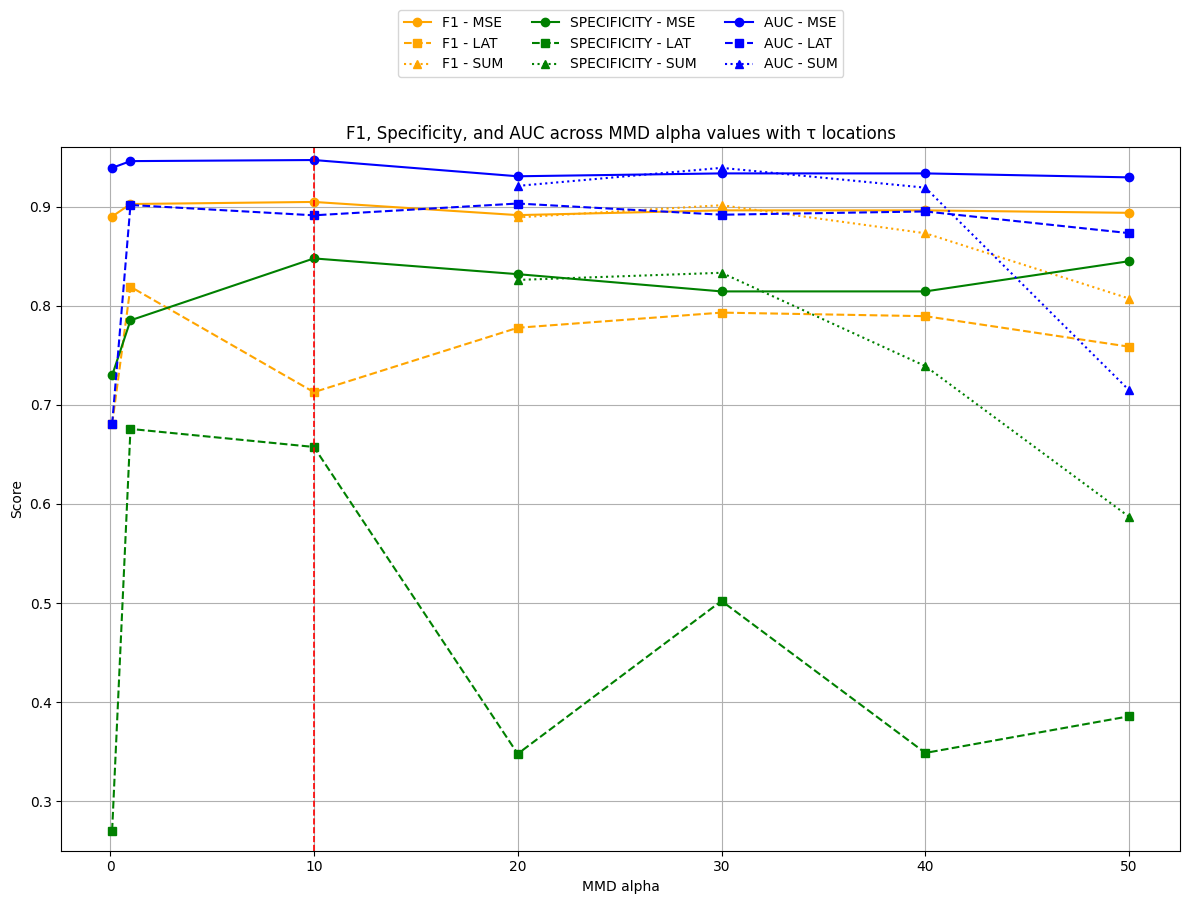

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Updated data extracted from the table
data = {
    'w': ['0.1', '0.1', '1', '1', '10', '10', '20', '20', '20',
          '30', '30', '30', '40', '40', '40', '50', '50', '50'],
    'tau_location': ['MSE', 'LAT', 'MSE', 'LAT', 'MSE', 'LAT',
                     'MSE', 'LAT', 'SUM', 'MSE', 'LAT', 'SUM',
                     'MSE', 'LAT', 'SUM', 'MSE', 'LAT', 'SUM'],
    'specificity': [0.7297, 0.2703, 0.7853, 0.6757, 0.8478, 0.6575,
                    0.8319, 0.3478, 0.8261, 0.8145, 0.5021, 0.8333,
                    0.8145, 0.3487, 0.7391, 0.8450, 0.3857, 0.5870],
    'f1': [0.8901, 0.6805, 0.9027, 0.8192, 0.9048, 0.7128,
           0.8915, 0.7778, 0.8892, 0.8963, 0.7931, 0.9015,
           0.8963, 0.7895, 0.8732, 0.8938, 0.7587, 0.8073],
    'auc': [0.9392, 0.6805, 0.9460, 0.9017, 0.9471, 0.8913,
            0.9307, 0.9032, 0.9210, 0.9336, 0.8919, 0.9392,
            0.9336, 0.8952, 0.9192, 0.9296, 0.8733, 0.7147]
}

# Create DataFrame
df = pd.DataFrame(data)
df['w'] = df['w'].astype(float)

# Plotting
plt.figure(figsize=(12, 10))

# Styles for tau_location
styles = {
    'MSE': {'linestyle': '-', 'marker': 'o'},
    'LAT': {'linestyle': '--', 'marker': 's'},
    'SUM': {'linestyle': ':', 'marker': '^'}
}

# Colors for metrics
colors = {
    'f1': 'orange',
    'specificity': 'green',
    'auc': 'blue'
}

# Plot each metric for each tau location
for metric in ['f1', 'specificity', 'auc']:
    for tau_type in df['tau_location'].unique():
        subset = df[df['tau_location'] == tau_type]
        plt.plot(subset['w'], subset[metric],
                 label=f'{metric.upper()} - {tau_type}',
                 linestyle=styles[tau_type]['linestyle'],
                 marker=styles[tau_type]['marker'],
                 color=colors[metric])

# Add vertical reference line at MMD alpha = 10
plt.axvline(x=10, color='red', linestyle='--', linewidth=1.2)

# Labels and title
plt.xlabel('MMD alpha')
plt.ylabel('Score')
plt.title('F1, Specificity, and AUC across MMD alpha values with τ locations')
plt.grid(True)

# set y axis limits

plt.ylim(0.25, 0.96)
# Legend above plot in 2x3 grid
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.09), ncol=3, fancybox=True)
plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.show()


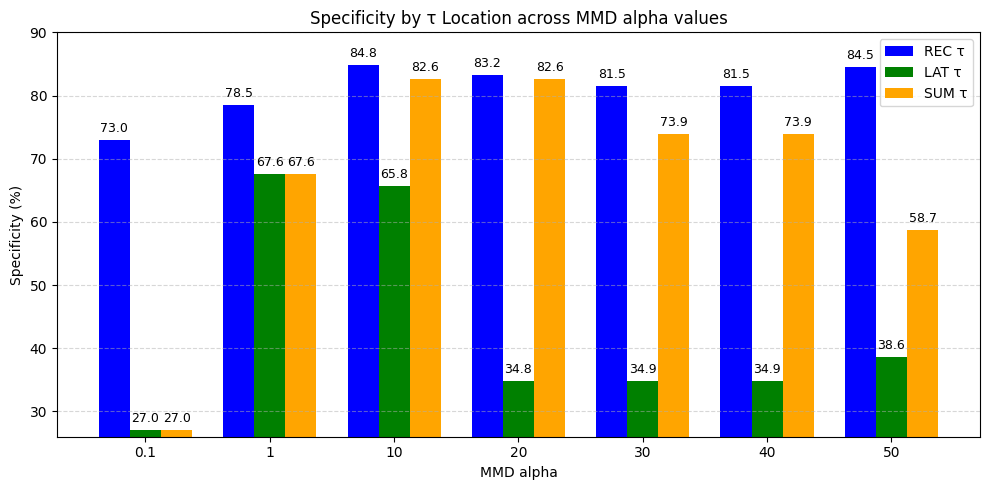

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# MMD alpha values
alphas = [0.1, 1, 10, 20, 30, 40, 50]
x = np.arange(len(alphas))
bar_width = 0.25

# Updated Specificity values in percentages
spec_mse = [72.97, 78.53, 84.78, 83.19, 81.45, 81.45, 84.50]
spec_lat = [27.03, 67.57, 65.75, 34.78, 34.87, 34.87, 38.57]
spec_sum = [27.03, 67.57, 82.61, 82.61, 73.91, 73.91, 58.70]

# Create plot
plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - bar_width, spec_mse, width=bar_width, color='blue', label='REC τ')
bars2 = plt.bar(x, spec_lat, width=bar_width, color='green', label='LAT τ')
bars3 = plt.bar(x + bar_width, spec_sum, width=bar_width, color='orange', label='SUM τ')

# Add value labels (percentages)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            plt.text(bar.get_x() + bar.get_width() / 2., height + 0.8,
                     f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# Axes and labels
plt.xticks(ticks=x, labels=[str(a) for a in alphas])
plt.xlabel('MMD alpha')
plt.ylabel('Specificity (%)')
plt.title('Specificity by τ Location across MMD alpha values')
plt.ylim(26, 90)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Loading desired network weights

In [5]:
import importlib
import models.latstats.network
import models.base.network
import models.morph.network
import models.sobel.network
import config.options
importlib.reload(models.latstats.network)
importlib.reload(models.base.network)
importlib.reload(models.morph.network)
importlib.reload(models.sobel.network)
importlib.reload(config.options)

from config.options import Options
opt = Options().parse()

from models.morph.network import GANLung  

# load_path = "/data/arumota/PhD/Pasantia/project2.0_mmd/results/weights/decoder_morph_mmd10_NLST_TL_DF_E500_LR0.00002_9010.pth"
load_path = "/data/arumota/PhD/Pasantia/project2.0_mmd/results/weights/decoder_morph_NLST_TE10_TR80.pth" 
print(f'Configuration options: {opt}')
LunGAN = GANLung(opt)
LunGAN.seed(41)
LunGAN.load_model(load_path)

from scripts.plotting import plot_classification_metrics, plot_confusion_matrix

def format_metrics(metrics_dict):
    # Create a list to hold the rows of the table
    rows = []
    
    # Collect the data for each model and metric, excluding 'latent'
    for model, metrics in metrics_dict.items():
        # if model == "latent":
        #     continue  # Skip the 'latent' model
        row = {"Model": model}
        for metric_name, value in metrics.items():
            row[metric_name] = value
        rows.append(row)
    
    # Create a DataFrame from the collected rows
    df = pd.DataFrame(rows)
    
    return df

            
tester = GANTester(LunGAN, train_loader, test_loader, LunGAN.device)
# Antes estaba en 0.8, ahora lo bajamos a 0.7
tester.alpha = 0.8
best_thresholds = tester.get_threshold_precision_recall(train_loader)
print(f'Best thresholds: {best_thresholds}')
metrics, y_true, scores = tester.test()
# best_thresholds = {'mse': 0.0097630290, 'sum': 0.02, 'latent': 0.02}
classification_results, _ = tester.calculate_classification_metrics(best_thresholds, metrics, y_true=y_true, scores=scores)
# plot_classification_metrics(classification_results)
# plot_confusion_matrix(y_true, y_pred, title='Test Set Confusion Matrix')
format_metrics(classification_results)

Configuration options: <config.options.Options._dict_to_obj.<locals>.ConfigObject object at 0x7ff4441724d0>
Loading model from /data/arumota/PhD/Pasantia/project2.0_mmd/results/weights/decoder_morph_NLST_TE10_TR80.pth
Best thresholds: {'mse': 0.010659214, 'latent': 0.38122648, 'sum': 0.0847726672887802}


,Model,TN,FP,FN,TP,specificity,recall,precision,f1,auc
0,mse,90,49,24,91,0.647482,0.791304,0.650000,0.713725,0.814013
1,latent,121,18,27,88,0.870504,0.765217,0.830189,0.796380,0.877510
2,sum,119,20,23,92,0.856115,0.800000,0.821429,0.810573,0.876759


Class 0 scores: (139,), Class 1 scores: (115,)


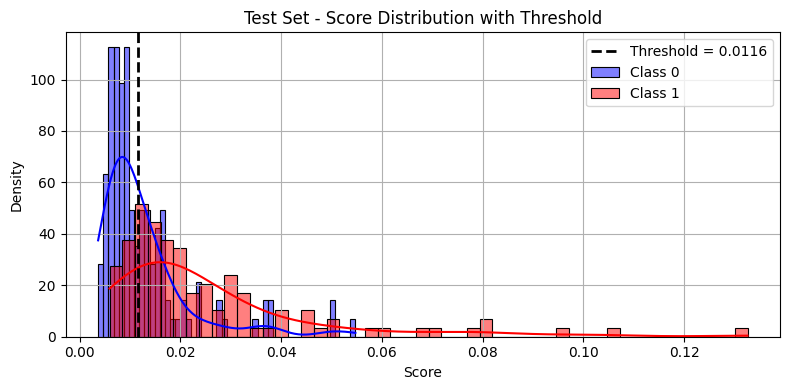

NameError: name 'y_train_true' is not defined

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_score_distribution(y_true, scores, threshold, title="Test Set - Score Distribution with Threshold"):
    plt.figure(figsize=(8, 4))
    
    # Convert to NumPy arrays
    scores = np.array(scores["mse"])
    y_true = np.array(y_true)
    
    # Separate scores for the two classes
    class_0_scores = scores[y_true == 0]
    class_1_scores = scores[y_true == 1]

    print(f'Class 0 scores: {class_0_scores.shape}, Class 1 scores: {class_1_scores.shape}')

    # Plot distributions
    sns.histplot(class_0_scores, color='blue', label='Class 0', kde=True, bins=50, stat='density')
    sns.histplot(class_1_scores, color='red', label='Class 1', kde=True, bins=50, stat='density')

    # Plot threshold line
    plt.axvline(x=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')

    plt.title(title)
    plt.xlabel("Score")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_score_distribution_train(y_true, mse_train, threshold, title="Score Distribution with Threshold"):
    plt.figure(figsize=(8, 4))
    
    # Convert to NumPy arrays
    scores = np.array(mse_train)
    y_true = np.array(y_true)
    
    # Separate scores for the two classes
    class_0_scores = scores[y_true == 0]
    class_1_scores = scores[y_true == 1]

    # Plot distributions
    sns.histplot(class_0_scores, color='blue', label='Class 0', kde=True, bins=50, stat='density')
    sns.histplot(class_1_scores, color='red', label='Class 1', kde=True, bins=50, stat='density')

    # Plot threshold line
    plt.axvline(x=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')

    plt.title(title)
    plt.xlabel("Score")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_score_distribution(y_true, scores, best_thresholds["mse"])
plot_score_distribution_train(y_train_true, mse_train, best_thresholds["mse"], title="Train Set - Score Distribution with Threshold")


In [ ]:
from skimage import morphology
import torch.nn.functional as F

def plot_full_group_grid_fixed_tight(
    group,
    y_true, y_pred, scores,
    real_images, recon_images,
    ascending=True,
    images_per_row=6
):
    group_indices = {
        "TP": [i for i in range(len(y_true)) if y_true[i] == 1 and y_pred[i] == 1],
        "TN": [i for i in range(len(y_true)) if y_true[i] == 0 and y_pred[i] == 0],
        "FP": [i for i in range(len(y_true)) if y_true[i] == 0 and y_pred[i] == 1],
        "FN": [i for i in range(len(y_true)) if y_true[i] == 1 and y_pred[i] == 0],
    }

    indices = group_indices[group]
    if not indices:
        print(f"No samples found for group: {group}")
        return
    
    print(f"Group: {group}, Number of samples: {len(indices)}, type: {type(indices)}")
    print(f"Grouop indices: {group_indices}")

    sorted_indices = sorted(indices, key=lambda i: scores[i], reverse=not ascending)

    n = len(sorted_indices)
    n_cols = images_per_row
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(2 * n_rows, n_cols, figsize=(n_cols * 2, n_rows * 4),
                             gridspec_kw=dict(wspace=0.05, hspace=0.0))

    axes = np.array(axes).reshape(2 * n_rows, n_cols)

    for ax in axes.flatten():
        ax.axis("off")

    for plot_idx, idx in enumerate(sorted_indices):
        row = plot_idx // n_cols
        col = plot_idx % n_cols

        real = real_images[idx]#.squeeze()
        recon = recon_images[idx]#.squeeze()
        true = y_true[idx]
        pred = y_pred[idx]
        score = scores[idx]


        real_img = torch.tensor(real).cuda()
        gene_img = torch.tensor(recon).cuda()

        # === SOBEL MAP (copied from SobelPixelLoss)
        sobel_x = torch.tensor([[1, 0, -1],
                                [2, 0, -2],
                                [1, 0, -1]], dtype=torch.float32).view(1, 1, 3, 3).to('cuda')

        sobel_y = torch.tensor([[1, 2, 1],
                                [0, 0, 0],
                                [-1, -2, -1]], dtype=torch.float32).view(1, 1, 3, 3).to('cuda')
        
        grad_x_recon = F.conv2d(gene_img, sobel_x, padding=1)
        grad_y_recon = F.conv2d(gene_img, sobel_y, padding=1)
        grad_recon   = torch.sqrt(grad_x_recon**2 + grad_y_recon**2).squeeze().detach().cpu().numpy()

        grad_x_real = F.conv2d(real_img, sobel_x, padding=1)
        grad_y_real = F.conv2d(real_img, sobel_y, padding=1)
        grad_real   = torch.sqrt(grad_x_real**2 + grad_y_real**2).squeeze().detach().cpu().numpy()
        sobel_map = grad_real + grad_recon

        # === MORPHOLOGICAL MAP (copied from MorphologicalPixelLoss)
        kernel = morphology.disk(3)
        real_openings = [morphology.opening(img.squeeze().detach().cpu().numpy(), kernel) for img in real_img]
        reco_openings = [morphology.opening(img.squeeze().detach().cpu().numpy(), kernel) for img in gene_img]
        real_openings = torch.stack([torch.tensor(img) for img in real_openings]).squeeze().detach().cpu().numpy()
        reco_openings = torch.stack([torch.tensor(img) for img in reco_openings]).squeeze().detach().cpu().numpy()
        tophat_real = (real_img - torch.tensor(real_openings).cuda()).detach()
        tophat_fake = (gene_img - torch.tensor(reco_openings).cuda()).detach()
        morph_map = tophat_real ** 2 + tophat_fake ** 2

        # === Combine maps by summing them
        combined_map = morph_map.squeeze().detach().cpu().numpy() + sobel_map
        combine_real_map = grad_real + real_openings
        combine_reco_map = grad_recon + reco_openings

        ax_real = axes[row * 2][col]
        ax_recon = axes[row * 2 + 1][col]

        # ax_real.imshow(grad_recon, cmap="gray")
        # ax_real.imshow(real_openings, cmap="gray")
        # ax_real.imshow(combine_real_map, cmap="gray")
        ax_real.imshow(combined_map, cmap="gray")
        # ax_real.imshow(real.squeeze(), cmap="gray")

        ax_real.set_title(f"Real | True={true}", fontsize=7)
        ax_real.axis("off")

        # ax_recon.imshow(grad_recon, cmap="gray")
        # ax_recon.imshow(reco_openings, cmap="gray")
        ax_recon.imshow(combine_reco_map, cmap="gray")
        # ax_recon.imshow(recon.squeeze(), cmap="gray")
        
        ax_recon.set_title(f"Recon | Pred={pred}, Score={score:.4f}", fontsize=7)
        ax_recon.axis("off")

    plt.suptitle(f"{group}: Real vs Reconstruction – {n} Samples", fontsize=14)
    plt.subplots_adjust(top=0.93, bottom=0.05)
    plt.show()

y_pred_mse = y_pred['mse'].astype(np.float32)
# Call for each group
plot_full_group_grid_fixed_tight("TP", y_true, y_pred_mse, scores['mse'], tester.real_images, tester.generated_images)
plot_full_group_grid_fixed_tight("TN", y_true, y_pred_mse, scores['mse'], tester.real_images, tester.generated_images)
plot_full_group_grid_fixed_tight("FP", y_true, y_pred_mse, scores['mse'], tester.real_images, tester.generated_images)
plot_full_group_grid_fixed_tight("FN", y_true, y_pred_mse, scores['mse'], tester.real_images, tester.generated_images)


In [ ]:
len(y_true)

# LNDB

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from skimage.transform import resize, rescale
from scipy.ndimage import rotate



class DataLoader:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.df = pd.read_csv('/data/Datasets/Lungs/CSVs/meta_created_info_3d_4R.csv')
        self.folder4R = self.df['folder'].tolist()
        self.train_samples = []
        self.max_shape = (32, 32)
        self.resized_images = []
        self.malignance_values = self.df['malignancy'].tolist()
        self.images = []
        self.images_labels = []
        self.benign = []
        self.malignant = []
        self.count = 0
        self.o3, self.b3 = 0, 0
        self.all = []
        self.test_malignant_data = []
        self.val_malignant_data = []
        self.train_malignant_data = []
    def load_samples(self):
        for folder_name in self.folder4R:
            folder_dir = os.path.join(self.folder_path, folder_name)
            if not os.path.isdir(folder_dir):
                continue
            # Get the list of npy files in the current folder
            npy_files_unsorted = [file_name for file_name in os.listdir(folder_dir) if file_name.endswith('.npy')]
            npy_files = sorted(npy_files_unsorted)
            # Calculate the index of the middle npy file
            middle_index = len(npy_files) // 2
            # Append the middle npy file to the train_samples list
            file_path = os.path.join(folder_dir, npy_files[middle_index])
            npy_data = np.load(file_path)
            self.train_samples.append(npy_data)
    def resize_images(self):
        for image in self.train_samples:
            # Resize the image while maintaining aspect ratio
            resized_image = resize(image, self.max_shape, mode='wrap', anti_aliasing=False)
            self.resized_images.append(resized_image)
        self.resized_images = [(sample - np.min(sample)) / (np.max(sample) - np.min(sample)) for sample in self.resized_images]
    def separate_images(self):
        for idx in range(len(self.malignance_values)):
            if self.malignance_values[idx] < 3:
                self.benign.append(self.resized_images[idx])
            if self.malignance_values[idx] > 3:
                self.malignant.append(self.resized_images[idx])
        self.all = self.benign+self.malignant
        print("Len Malignance: {}".format(len(self.malignant)))
        print("Len Benign: {}".format(len(self.benign)))
        self.values = [0] * len(self.benign) + [1] * len(self.malignant)
        print("Len All: {}".format(len(self.all)))
        
    def split_data(self, sizeTest, sizeTrain, sizeBenign):
        random_state = 42
        self.test_benign_data, self.x_benign_data = train_test_split(self.benign, test_size=sizeTest, random_state=random_state)
        self.val_benign_data, self.train_benign_data = train_test_split(self.x_benign_data, test_size=sizeTrain, random_state=random_state)
        self.test_malignant_data, self. train_malignant_data = train_test_split(self.malignant, test_size=sizeBenign, random_state=random_state)
        print("Len test_benign_data: {}".format(len(self.test_benign_data)))
        print("Len val_benign_data: {}".format(len(self.val_benign_data)))
        print("Len train_benign_data: {}".format(len(self.train_benign_data)))
        print("Len train_malignant: {}".format(len(self.train_malignant_data)))
        print("Len test_malignant: {}".format(len(self.test_malignant_data)))

folder_path = '/data/Datasets/Lungs/LIDC-IDRI/LIDC-IDRI_images_npy_3d_HU/'
s = DataLoader(folder_path)
s.load_samples()
s.resize_images()
s.separate_images()
s.split_data(0.5, 0.98, 0.6)

import random
random.seed(42)

def random_rotate(image):
    angle = random.choice([90, 180, 270])
    return rotate(image, angle, reshape=False)

def random_flip(image):
    flip_type = random.choice(["horizontal", "vertical"])
    if flip_type == "horizontal":
        return np.fliplr(image)
    else:  # vertical flip
        return np.flipud(image)

def augment_data(dataset, max_augmented_size=1000):
    augmented_dataset = []
    augmented_data = []
    operations = [random_rotate, random_flip]

    for image in dataset:
        for op in operations:
            augmented_data.append(op(image))
            if len(augmented_data) >= max_augmented_size:
                return augmented_data[:max_augmented_size]
    
    return augmented_data

augmented_dataset = augment_data(s.train_benign_data)
s.train_benign_data = augmented_dataset
augmented_dataset = augment_data(s.train_benign_data)
s.train_benign_data = augmented_dataset
# 

print(len(s.train_benign_data))
print(len(s.train_malignant_data))
print(len(s.test_benign_data))
print(len(s.test_malignant_data))


import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class CustomDataset(Dataset):
    def __init__(self, data_list, dataset_type='train', labels=None):
        self.data_list = data_list
        self.dataset_type = dataset_type
        self.labels = labels

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        data = self.data_list[idx]
        data = np.expand_dims(data, axis=0)  # Add channel dimension for grayscale images
        data = np.ascontiguousarray(data)    # Ensure the array is contiguous in memory
        if self.dataset_type == 'test' and self.labels is not None:
            label = self.labels[idx]
            return torch.from_numpy(data).float(), torch.tensor(label).float()
        return torch.from_numpy(data).float()

class CombinedDataset:
    def __init__(self, train_benign_data, test_benign_data, test_malignant_data):
        # Generate labels for test data
        test_labels = [0] * len(test_benign_data) + [1] * len(test_malignant_data)
        test_data = test_benign_data + test_malignant_data
        
        self.datasets = {
            'train': CustomDataset(train_benign_data, dataset_type='train'),
            'test': CustomDataset(test_data, dataset_type='test', labels=test_labels)
        }

    def __getitem__(self, dataset_type):
        return self.datasets[dataset_type]


# Initialize the combined dataset
combined_dataset = CombinedDataset(s.train_benign_data, s.test_benign_data, s.test_malignant_data)

# Create DataLoaders
train_loader = DataLoader(combined_dataset['train'], batch_size=opt.batchsize, shuffle=True)
test_loader = DataLoader(combined_dataset['test'], batch_size=opt.batchsize, shuffle=False)

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/data/Datasets/Lungs/LNDb/CSVs/nodules_consensous.csv")
df_filtered = df[(df["RadID"] == 3) & (df["malignancy"] != 2)]
df_filtered.to_csv("/home/arumota_pupils/Josue/Datasets/LNDb/nodules_consensous_filtered3R.csv", index=False)

In [ ]:
df = pd.read_csv("/data/Datasets/Lungs/LNDb/CSVs/nodules_consensous.csv")
df_filtered = df[(df["RadID"] == 3) & (df["malignancy"] != 2)]
df_filtered = pd.concat([df_filtered, df[(df["RadID"] == 2) & (df["malignancy"] != 2)]])
df_filtered.to_csv("/home/arumota_pupils/Josue/Datasets/LNDb/nodules_consensous_filtered2R.csv", index=False)

In [ ]:
import os
import numpy as np
import pandas as pd
from skimage.transform import resize
import torch
from torch.utils.data import Dataset, DataLoader

# Define a dataset class for the test data
class TestDataset(Dataset):
    def __init__(self, data_list, labels):
        self.data_list = data_list
        self.labels = labels

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        data = self.data_list[idx]
        data = np.expand_dims(data, axis=0)  # Add channel dimension for grayscale images
        data = np.ascontiguousarray(data)    # Ensure the array is contiguous in memory
        label = self.labels[idx]
        return torch.from_numpy(data).float(), torch.tensor(label).float()


# Función para filtrar solo los nódulos benignos (y == 0)
def create_benign_dataset(X_data, y_data):
    benign_indices = np.where(y_data == 0)[0]  # Obtiene los índices de las muestras benignas
    X_benign = X_data[benign_indices]
    y_benign = y_data[benign_indices]
    return X_benign, y_benign

# Load the CSV file
df = pd.read_csv("/home/arumota_pupils/Josue/Datasets/LNDb/nodules_consensous_filtered3R.csv")
FOLDER3R = df['nodule']
LNDbPATH = '/data/Datasets/Lungs/LNDb/LNDb_cropped_2D/'

# Load the nodule data
unresizedLNDb = [np.load(os.path.join(LNDbPATH, npy + ".npy")) for npy in FOLDER3R]
# Resize the images
max_shape = (32, 32)
LNDb = [resize(image, max_shape, mode='wrap', anti_aliasing=False) for image in unresizedLNDb]
LNDb = [(sample - np.min(sample)) / (np.max(sample) - np.min(sample)) for sample in LNDb]

# Separate the nodules into benign and malignant based on the malignancy value
malignantLNDb = []
benignLNDb = []
ValuesLNDb = df['malignancy'].tolist()
for idx in range(len(ValuesLNDb)):
    if ValuesLNDb[idx] < 2:
        benignLNDb.append(LNDb[idx])
    elif ValuesLNDb[idx] > 2:
        malignantLNDb.append(LNDb[idx])

# Combine benign and malignant nodules
allLNDb = benignLNDb + malignantLNDb
labelsLNDb = [0] * len(benignLNDb) + [1] * len(malignantLNDb)

X_train, X_test, y_train, y_test = train_test_split(allLNDb, labelsLNDb, test_size=0.7, random_state=42)

# Create the test dataset
test_dataset_new = TestDataset(X_test, y_test)
test_loader_new_arch = DataLoader(test_dataset_new, batch_size=opt.batchsize, shuffle=False)

train_dataset_new = TestDataset(X_train, y_train)
train_loader_new_arch = DataLoader(train_dataset_new, batch_size=opt.batchsize, shuffle=False)

In [ ]:
model_num = 91053770
load_path = os.path.join(opt.save_path, "weights", f'ganlung_{model_num}.pth')

load_path = "/home/arumota_pupils/Josue/2EMBC_Extention/project2.0_mmd/results/weights/decoder_sobel_mmd10_2.pth"

LunGAN = GANLung(opt)
LunGAN.seed(41)
LunGAN.load_model(load_path)

def format_metrics(metrics_dict):
    # Create a list to hold the rows of the table
    rows = []
    
    # Collect the data for each model and metric, excluding 'latent'
    for model, metrics in metrics_dict.items():
        if model == "latent":
            continue  # Skip the 'latent' model
        row = {"Model": model}
        for metric_name, value in metrics.items():
            row[metric_name] = value
        rows.append(row)
    
    # Create a DataFrame from the collected rows
    df = pd.DataFrame(rows)
    
    return df

            
tester = GANTester(LunGAN, train_loader_new_arch, test_loader_new_arch, LunGAN.device)
tester.alpha = 0.8
best_thresholds = tester.get_threshold_precision_recall(train_loader_new_arch)
metrics, y_true, scores = tester.test()
classification_results, __ = tester.calculate_classification_metrics(best_thresholds, metrics, y_true=y_true, scores=scores)
# plot_classification_metrics(classification_results)
# plot_confusion_matrix(y_true, y_pred, title='Test Set Confusion Matrix')
format_metrics(classification_results)

## Fine - Tuning

In [ ]:
f_epoch = 30

# Assuming X_train and y_train are lists or some unsupported type
X_train = np.array(X_train)  # Convert X_train to a NumPy array
y_train = np.array(y_train)  # Convert y_train to a NumPy array

def fine_tune_ganlung(opt, X_train, y_train):
    # Filtrar solo los nódulos benignos (y == 0)
    X_benign, y_benign = create_benign_dataset(X_train, y_train)

    # Crear el dataset y DataLoader para las muestras benignas
    train_dataset_benign = TestDataset(X_benign, y_benign)
    train_loader_benign = DataLoader(train_dataset_benign, batch_size=opt.batchsize, shuffle=True)

    # Cargar el modelo preentrenado
    lungan = GANLung(opt)
    lungan.load_model(load_path)
    lungan.seed(opt.seed)

    # Diccionario para almacenar las pérdidas durante el entrenamiento
    all_losses = {
        'err_g': [],
        'err_d': [],
        'err_g_con': [],
        'err_g_adv': [],
        'err_g_enc': []
    }

    # Bucle de fine-tuning
    for epoch in range(f_epoch):
        for i, (data, labels) in enumerate(train_loader_benign):
            # Asegurarse de que los datos están en el tipo correcto (float32) y moverlos al dispositivo
            input = data.to(lungan.device).float()  # Convertir a float32 y mover al dispositivo
            labels = labels.to(lungan.device).float()  # Convertir las etiquetas a float32 si es necesario

            # Optimizar los parámetros (continuar entrenando el generador y el discriminador)
            err_g, err_d, err_g_con, err_g_adv, err_g_enc = lungan.optimize_params(input)

            # Mostrar y registrar las pérdidas cada 100 iteraciones
            if i % 100 == 0:
                print(f'Epoch [{epoch}/{f_epoch}], Step [{i}/{len(train_loader_benign)}], '
                      f'G Loss: {err_g.item():.5f}, D Loss: {err_d.item():.5f}, '
                      f'G Con Loss: {err_g_con.item():.5f}, G Adv Loss: {err_g_adv.item():.5f}, '
                      f'G Enc Loss: {err_g_enc.item():.5f}')
                
                all_losses['err_g'].append(err_g.item())
                all_losses['err_d'].append(err_d.item())
                all_losses['err_g_con'].append(err_g_con.item())
                all_losses['err_g_adv'].append(err_g_adv.item())
                all_losses['err_g_enc'].append(err_g_enc.item())
    return lungan

LunGAN = fine_tune_ganlung(opt, X_train, y_train)

In [ ]:
tester = GANTester(LunGAN, train_loader_new_arch, test_loader_new_arch, LunGAN.device)
best_thresholds = tester.get_threshold_precision_recall(train_loader_new_arch)
# Test the model
results = tester.test(80)
# Plot histograms
plot_histograms(results, best_thresholds)

In [ ]:
print(return_metrics(results["mse_0"], results["mse_1"], best_thresholds["x"]))
print("#")

print(return_metrics(results["mse_latent_0"], results["mse_latent_1"], best_thresholds["latent"]))
print("#")

print(return_metrics(results["sum_mse_0"], results["sum_mse_1"], best_thresholds["sum"]))
print("#")

## Latent Spaces

In [ ]:
tester.plot_tsne()
tester.plot_pca()

In [ ]:
index_to_plot = 45  # Change this to plot a different index
plot_images(results['real_images'], results['generated_images'], index_to_plot)

In [ ]:
from data import CustomDatasetV4
from options import Options
opt = Options().parse()

def count_data_per_fold_and_type(main_folder):
    fold_stats = {}
    for fold in range(10):
        fold_stats[fold] = {'train_benign': 0, 'train_malignant': 0, 'test_benign': 0, 'test_malignant': 0}
        
        # Initialize train and test datasets
        train_dataset = CustomDatasetV4(main_folder, num_fold=fold, dataset_type='train')
        test_dataset = CustomDatasetV4(main_folder, num_fold=fold, dataset_type='test')

        # Count benign samples in the training dataset
        fold_stats[fold]['train_benign'] = len(train_dataset)
        # Training set only contains benign samples, so 'train_malignant' is always 0
        fold_stats[fold]['train_malignant'] = 0

        # Count benign and malignant samples in the test dataset
        for _, label in test_dataset:
            if label.item() == 0:
                fold_stats[fold]['test_benign'] += 1
            elif label.item() == 1:
                fold_stats[fold]['test_malignant'] += 1

    return fold_stats

# Count the data per fold
fold_data_counts = count_data_per_fold_and_type(opt.folder_path)

# Print the results
for fold, counts in fold_data_counts.items():
    print(f"Fold {fold}:")
    print(f"  Train benign (0): {counts['train_benign']}")
    print(f"  Train malignant (1): {counts['train_malignant']}")
    print(f"  Test benign (0): {counts['test_benign']}")
    print(f"  Test malignant (1): {counts['test_malignant']}")

In [ ]:
import matplotlib.pyplot as plt
# Test
s = np.load("/home/arumota_pupils/Josue/EMBC_Extention/Data/test/benign/nodule_539.npy")
print(s.shape)
plt.imshow(s, cmap='gray')

# Histopathological Inference

## Dataloader

In [ ]:
import pandas as pd
import numpy as np
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader
from skimage.transform import resize

class NoduleDataset(Dataset):
    def __init__(self, hist, npy_dir):
        """
        Args:
            hist (pd.DataFrame): DataFrame containing metadata (must include 'nodule_id' and 'malignancy').
            npy_dir (str): Directory containing .npy files for nodules.
        """
        # Filter the DataFrame based on conditions
        hist = hist.loc[
            (hist['malignancy'] > 0) &
            (hist['method'] != 0) &
            (hist['malignancy'] != 3.0)
        ]
        hist = hist[~hist['nodule_id'].str.startswith("LIDC-IDRI-0332")]

        # Map malignancy: 1 → 0, everything else → 1
        hist.loc[:, 'malignancy'] = hist['malignancy'].map(lambda x: 0 if x == 1 else 1)

        self.npy_dir = npy_dir
        self.nodule_ids = []
        self.labels = []
        self.missing_files = []

        # Check for missing files and filter the dataset
        for nodule_id, label in zip(hist['nodule_id'], hist['malignancy']):
            file_pattern = os.path.join(self.npy_dir, f"{nodule_id}.npy")  # Updated pattern

            # Match files based on the new naming convention
            matching_files = glob.glob(file_pattern)

            if len(matching_files) == 0:
                # Record missing files but skip them
                self.missing_files.append(nodule_id)
                continue
            elif len(matching_files) > 1:
                raise ValueError(f"Multiple files found for nodule ID: {nodule_id} - {matching_files}")
            
            # Add the valid file and label
            self.nodule_ids.append(matching_files[0])  # Store the full file path
            self.labels.append(label)

        # Print missing files if any
        if self.missing_files:
            print(f"Warning: {len(self.missing_files)} files not found. Missing nodule IDs:")
            print(", ".join(self.missing_files))

        # Check if no valid samples are left
        if len(self.nodule_ids) == 0:
            raise ValueError("No valid samples found after filtering and file matching.")

    def __len__(self):
        # Returns the total number of samples
        return len(self.nodule_ids)

    def __getitem__(self, idx):
        # Get the file path and corresponding label
        file_path = self.nodule_ids[idx]
        label = self.labels[idx]

        # Load the .npy file
        npy_data = np.load(file_path)

        # Add preprocessing steps
        # Resize the data to (1, 32, 32)
        npy_data_resized = resize(npy_data, (32, 32), mode='wrap', anti_aliasing=False)

        # Apply MinMax normalization
        npy_min = npy_data_resized.min()
        npy_max = npy_data_resized.max()
        if npy_max > npy_min:  # Avoid division by zero
            npy_data_resized = (npy_data_resized - npy_min) / (npy_max - npy_min)
        else:
            npy_data_resized = npy_data_resized - npy_min  # All zeros in this case

        # Add channel dimension and convert to tensor
        npy_data_resized = np.expand_dims(npy_data_resized, axis=0)  # [32, 32] -> [1, 32, 32]
        sample_tensor = torch.from_numpy(npy_data_resized).float()
        label_tensor = torch.tensor(label).float()

        return sample_tensor, label_tensor

# Function to create a DataLoader
def create_dataloader(hist, npy_dir, batch_size=16, shuffle=True):
    dataset = NoduleDataset(hist, npy_dir)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return data_loader

# Test the updated code
hist = pd.read_csv("/data/Josue/Datasets/LIDC/csv/transformed_hist.csv")
npy_dir = "/data/Josue/Datasets/LIDC/1_radiologist"

batch_size = 16
try:
    test_hist = create_dataloader(hist, npy_dir, batch_size=batch_size, shuffle=True)

    # Iterate through the DataLoader
    for i, (sample_batch, diagnosis_batch) in enumerate(test_hist):
        print(f"Batch {i+1}")
        print("Samples:", sample_batch.shape)  # Should be [batch_size, 1, 32, 32]
        print("Diagnoses:", diagnosis_batch)  # Binary values: 0 (benign), 1 (malignant)

except ValueError as e:
    print(f"Error: {e}")

In [ ]:
import os

# === PATHS & SETTINGS ===
base_weights_path = "/home/arumota_pupils/Josue/2EMBC_Extention/project2.0_mmd/results/weights"
w_values = [0.1, 1.0, 10, 20, 30, 50]

# Load HIST data
hist = pd.read_csv("/data/Josue/Datasets/LIDC/csv/transformed_hist.csv")
npy_dir = "/data/Josue/Datasets/LIDC/1_radiologist"

# === Load HIST test set ===
test_hist = create_dataloader(hist, npy_dir, batch_size=16, shuffle=False)  # for reproducibility

# === Results containers ===
mse_results = {}
sum_results = {}
latent_results = {}

# === Main loop ===
for w in w_values:
    print(f"\n=== Testing model with w = {w} ===")
    model_filename = f"model_wmmd_{w}.pth"
    load_path = os.path.join(base_weights_path, model_filename)

    if not os.path.exists(load_path):
        print(f"❌ File not found: {load_path}")
        continue

    # Load model
    LunGAN = GANLung(opt)
    LunGAN.seed(41)
    LunGAN.load_model(load_path)

    # Evaluate model on HIST
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    tester = GANTester(LunGAN, train_loader, test_hist, LunGAN.device)
    tester.alpha = 0.8
    best_thresholds = tester.get_threshold_precision_recall(train_loader)
    metrics, y_true, scores = tester.test()
    classification_results, _ = tester.calculate_classification_metrics(
        best_thresholds, metrics, y_true=y_true, scores=scores
    )

    # Store results
    if "mse" in classification_results:
        mse_results[w] = classification_results["mse"]
    if "sum" in classification_results:
        sum_results[w] = classification_results["sum"]
    if "latent" in classification_results:
        latent_results[w] = classification_results["latent"]

# === Function to print tables ===
def print_metric_table(results_dict, label="mse"):
    print(f"\n### Results for: {label.upper()} (HIST dataset) ###")
    print("w\tspecificity\trecall\tprecision\tf1\tauc")
    for w in sorted(results_dict.keys()):
        m = results_dict[w]
        print(f"{w}\t{m['specificity']:.4f}\t{m['recall']:.4f}\t{m['precision']:.4f}\t{m['f1']:.4f}\t{m['auc']:.4f}")

# === Final Output ===
print_metric_table(mse_results, "mse")
print_metric_table(sum_results, "sum")
print_metric_table(latent_results, "latent")


In [ ]:
import importlib
import models.latstats.network
import models.base.network
import models.morph.network
import models.sobel.network
import config.options
importlib.reload(models.latstats.network)
importlib.reload(models.base.network)
importlib.reload(models.morph.network)
importlib.reload(models.sobel.network)
importlib.reload(config.options)
from train.test import GANTester

from config.options import Options
opt = Options().parse()

from models.morph.network import GANLung  

load_path = "/home/arumota_pupils/Josue/2EMBC_Extention/project2.0_mmd/results/weights/decoder_morph_mmd10_2.pth"

LunGAN = GANLung(opt)
LunGAN.seed(41)
LunGAN.load_model(load_path)

def format_metrics(metrics_dict):
    # Create a list to hold the rows of the table
    rows = []
    
    # Collect the data for each model and metric, excluding 'latent'
    for model, metrics in metrics_dict.items():
        if model == "latent":
            continue  # Skip the 'latent' model
        row = {"Model": model}
        for metric_name, value in metrics.items():
            row[metric_name] = value
        rows.append(row)
    
    # Create a DataFrame from the collected rows
    df = pd.DataFrame(rows)
    
    return df


train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
tester = GANTester(LunGAN, train_loader, test_hist, LunGAN.device)
tester.alpha = 0.8
best_thresholds = tester.get_threshold_precision_recall(train_loader)
metrics, y_true, scores_dict = tester.test()
classification_results, y_pred_t = tester.calculate_classification_metrics(best_thresholds, metrics, y_true=y_true, scores=scores_dict)
# plot_classification_metrics(classification_results)
# plot_confusion_matrix(y_true, y_pred, title='Test Set Confusion Matrix')
format_metrics(classification_results)

### Reconstructions plotting

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_reconstructions(real_images, reconstructed_images, labels, predictions=None, indices=None, n=5, title="Real vs Reconstructed"):
    """
    Plot original and reconstructed images side by side.
    """
    if indices is None:
        indices = range(n)
    
    plt.figure(figsize=(4 * n, 4))
    
    for i, idx in enumerate(indices):
        real = real_images[idx].squeeze()
        recon = reconstructed_images[idx].squeeze()
        
        plt.subplot(2, n, i + 1)
        plt.imshow(real, cmap='gray')
        true_label = labels[idx]
        pred_label = predictions[idx] if predictions is not None else "?"
        plt.title(f"Real\nTrue: {true_label} | Pred: {pred_label}")
        plt.axis('off')

        plt.subplot(2, n, n + i + 1)
        plt.imshow(recon, cmap='gray')
        plt.title(f"Reconstructed")
        plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from operator import itemgetter

# Convert your data into numpy arrays
y_true = np.array(tester.labels)
y_pred = np.array(y_pred_t["mse"]) 
scores = np.array(scores_dict["mse"])

# Group and sort by score
group_indices = {
    "TP": [i for i in range(len(y_true)) if y_true[i] == 1 and y_pred[i] == 1],
    "TN": [i for i in range(len(y_true)) if y_true[i] == 0 and y_pred[i] == 0],
    "FP": [i for i in range(len(y_true)) if y_true[i] == 0 and y_pred[i] == 1],
    "FN": [i for i in range(len(y_true)) if y_true[i] == 1 and y_pred[i] == 0],
}

def interactive_reconstruction_viewer(group="FP", ascending=True):
    indices = group_indices[group]

    if not indices:
        print(f"No samples in group: {group}")
        return

    # Sort indices by score
    sorted_indices = sorted(indices, key=lambda i: scores[i], reverse=not ascending)
    n = len(sorted_indices)

    slider = widgets.IntSlider(value=0, min=0, max=n - 1, step=1, description=f"{group} Index")

    def plot_sample(i):
        idx = sorted_indices[i]
        real_img = tester.real_images[idx].squeeze()
        recon_img = tester.generated_images[idx].squeeze()
        true_label = y_true[idx]
        pred_label = y_pred[idx]
        score_val = scores[idx]

        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(real_img, cmap='gray')
        plt.title(f"Real (True={true_label})")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(recon_img, cmap='gray')
        plt.title(f"Reconstructed (Pred={pred_label})")
        plt.axis("off")

        plt.suptitle(f"{group} | Index {idx} | Score = {score_val:.4f}", fontsize=14)
        plt.tight_layout()
        plt.show()

    widgets.interact(plot_sample, i=slider)

# 👉 Use like this:
interactive_reconstruction_viewer("TN", ascending=True)  # You can change to TP, TN, FN


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math

import matplotlib.pyplot as plt
import numpy as np
import math

def plot_full_group_grid_fixed_tight(
    group,
    y_true, y_pred, scores,
    real_images, recon_images,
    ascending=True,
    images_per_row=6
):
    group_indices = {
        "TP": [i for i in range(len(y_true)) if y_true[i] == 1 and y_pred[i] == 1],
        "TN": [i for i in range(len(y_true)) if y_true[i] == 0 and y_pred[i] == 0],
        "FP": [i for i in range(len(y_true)) if y_true[i] == 0 and y_pred[i] == 1],
        "FN": [i for i in range(len(y_true)) if y_true[i] == 1 and y_pred[i] == 0],
    }

    indices = group_indices[group]
    if not indices:
        print(f"No samples found for group: {group}")
        return

    sorted_indices = sorted(indices, key=lambda i: scores[i], reverse=not ascending)

    n = len(sorted_indices)
    n_cols = images_per_row
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(2 * n_rows, n_cols, figsize=(n_cols * 2, n_rows * 4),
                             gridspec_kw=dict(wspace=0.05, hspace=0.0))

    axes = np.array(axes).reshape(2 * n_rows, n_cols)

    for ax in axes.flatten():
        ax.axis("off")

    for plot_idx, idx in enumerate(sorted_indices):
        row = plot_idx // n_cols
        col = plot_idx % n_cols

        real = real_images[idx].squeeze()
        recon = recon_images[idx].squeeze()
        true = y_true[idx]
        pred = y_pred[idx]
        score = scores[idx]

        ax_real = axes[row * 2][col]
        ax_recon = axes[row * 2 + 1][col]

        ax_real.imshow(real, cmap="gray")
        ax_real.set_title(f"Real | True={true}", fontsize=7)
        ax_real.axis("off")

        ax_recon.imshow(recon, cmap="gray")
        ax_recon.set_title(f"Recon | Pred={pred}, Score={score:.4f}", fontsize=7)
        ax_recon.axis("off")

    plt.suptitle(f"{group}: Real vs Reconstruction – {n} Samples", fontsize=14)
    plt.subplots_adjust(top=0.93, bottom=0.05)
    plt.show()


# Call for each group
plot_full_group_grid_fixed_tight("TP", y_true, y_pred, scores, tester.real_images, tester.generated_images)
plot_full_group_grid_fixed_tight("TN", y_true, y_pred, scores, tester.real_images, tester.generated_images)
plot_full_group_grid_fixed_tight("FP", y_true, y_pred, scores, tester.real_images, tester.generated_images)
plot_full_group_grid_fixed_tight("FN", y_true, y_pred, scores, tester.real_images, tester.generated_images)


### Feature extraction for Hist TSNE Plotting

In [ ]:
import numpy as np

features = np.array([x.flatten() for x in tester.latent_outputs])

y_true = np.array(y_true)
y_pred = np.array(y_pred_t["mse"])

conditions = []


for true, pred in zip(y_true, y_pred):
    if true == 1 and pred == 1:
        conditions.append("TP")
    elif true == 0 and pred == 0:
        conditions.append("TN")
    elif true == 0 and pred == 1:
        conditions.append("FP")
    elif true == 1 and pred == 0:
        conditions.append("FN")


#### Color by Malignancy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

# ---------- Assume you already have ----------
# features (N, latent_dim)
# y_true, y_pred (both lists or arrays)
# These must all align with each other in length!

# --- Run t-SNE ---
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(features)

# --- Build DataFrame ---
tsne_df = pd.DataFrame({
    "TSNE-1": tsne_result[:, 0],
    "TSNE-2": tsne_result[:, 1],
    "True": y_true,
    "Pred": y_pred
})

# --- Add Ground Truth and Correctness info ---
tsne_df["GroundTruth"] = tsne_df["True"].map({0: "Benign", 1: "Malignant"})
tsne_df["Correct"] = tsne_df.apply(lambda row: "Correct" if row["True"] == row["Pred"] else "Incorrect", axis=1)

# --- Assign Color by Ground Truth ---
tsne_df["Color"] = tsne_df["GroundTruth"].map({
    "Benign": "#2166ac",     # blue
    "Malignant": "#1b7837"   # green
})

# --- Assign Marker by Correctness ---
tsne_df["Marker"] = tsne_df["Correct"].map({
    "Correct": "s",     # square
    "Incorrect": "D"    # diamond
})

# --- Plot ---
plt.figure(figsize=(10, 7))

# Plot each marker shape separately
for marker_type in ["s", "D"]:
    subset = tsne_df[tsne_df["Marker"] == marker_type]
    label = "Correct" if marker_type == "s" else "Incorrect"
    
    plt.scatter(
        subset["TSNE-1"], subset["TSNE-2"],
        c=subset["Color"],
        marker=marker_type,
        edgecolor='k',
        s=80,
        label=label,
        alpha=0.75
    )

# --- Custom Legend ---
legend_handles = [
    plt.Line2D([0], [0], marker='s', color='w', label='Correct', markerfacecolor='gray', markersize=10, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='D', color='w', label='Incorrect', markerfacecolor='gray', markersize=10, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Benign', markerfacecolor='#2166ac', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Malignant', markerfacecolor='#1b7837', markersize=10)
]
plt.legend(handles=legend_handles, title="Legend")

plt.title("t-SNE of Histopathological Nodules\nColor: Ground Truth | Shape: Prediction Accuracy")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.tight_layout()
plt.show()


#### Color by Spiculation

In [ ]:
from sklearn.metrics import silhouette_score

# Use original latent space, not t-SNE output
score = silhouette_score(features, y_true)  # or y_pred
print(f"Silhouette Score (GT labels): {score:.4f}")

from scipy.spatial.distance import cdist

benign = features[np.array(y_true) == 0]
malignant = features[np.array(y_true) == 1]

# Mean intra-class distance
intra_benign = np.mean(cdist(benign, benign))
intra_malignant = np.mean(cdist(malignant, malignant))

# Mean inter-class distance
inter_class = np.mean(cdist(benign, malignant))

print(f"Intra Benign: {intra_benign:.4f}")
print(f"Intra Malignant: {intra_malignant:.4f}")
print(f"Inter-class Distance: {inter_class:.4f}")

from sklearn.metrics import davies_bouldin_score

db_index = davies_bouldin_score(features, y_true)
print(f"Davies-Bouldin Index: {db_index:.4f}")

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=5)
acc = cross_val_score(knn, features, y_true, cv=5).mean()

print(f"kNN Accuracy in Latent Space: {acc:.4f}")


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assume: features, y_true, y_pred are defined

# --- PCA with 2 components ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

# --- Explained variance ratio ---
explained = pca.explained_variance_ratio_
print(f"PCA Explained Variance: PC1 = {explained[0]:.2%}, PC2 = {explained[1]:.2%}")

# --- Build DataFrame like t-SNE ---
pca_df = pd.DataFrame({
    "PC1": pca_result[:, 0],
    "PC2": pca_result[:, 1],
    "True": y_true,
    "Pred": y_pred
})
pca_df["GroundTruth"] = ["Benign" if y == 0 else "Malignant" for y in y_true]
pca_df["Correct"] = ["Correct" if t == p else "Incorrect" for t, p in zip(y_true, y_pred)]

# Map color and shape
pca_df["Color"] = pca_df["GroundTruth"].map({
    "Benign": "#2166ac",
    "Malignant": "#1b7837"
})
pca_df["Marker"] = pca_df["Correct"].map({
    "Correct": "s",
    "Incorrect": "D"
})

# --- Plot PCA ---
plt.figure(figsize=(10, 7))

for marker_type in ["s", "D"]:
    subset = pca_df[pca_df["Marker"] == marker_type]
    label = "Correct" if marker_type == "s" else "Incorrect"
    
    plt.scatter(
        subset["PC1"], subset["PC2"],
        c=subset["Color"],
        marker=marker_type,
        edgecolor='k',
        s=80,
        label=label,
        alpha=0.9
    )

# --- Custom Legend ---
legend_handles = [
    plt.Line2D([0], [0], marker='s', color='w', label='Correct', markerfacecolor='gray', markersize=10, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='D', color='w', label='Incorrect', markerfacecolor='gray', markersize=10, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Benign', markerfacecolor='#2166ac', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Malignant', markerfacecolor='#1b7837', markersize=10)
]
plt.legend(handles=legend_handles, title="Legend")

plt.title(f"PCA of Latent Space\nPC1: {explained[0]:.1%}, PC2: {explained[1]:.1%}")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()


In [ ]:
# Predictions for x 
y_pred = y_pred_t['mse']
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Indices
wrong_indices = np.where(y_true != y_pred)[0]
correct_indices = np.where(y_true == y_pred)[0]

# Dataset source (you already have this)
dataset = test_hist.dataset

# All 4 sample groups (file path, true, pred, score)
wrong_samples = [(dataset.nodule_ids[i], y_true[i], y_pred[i], scores_dict['mse'][i]) for i in wrong_indices]
correct_samples = [(dataset.nodule_ids[i], y_true[i], y_pred[i], scores_dict['mse'][i]) for i in correct_indices]

# Sub-classify
fp_samples = [s for s in wrong_samples if s[1] == 0 and s[2] == 1]
fn_samples = [s for s in wrong_samples if s[1] == 1 and s[2] == 0]
tn_samples = [s for s in correct_samples if s[1] == 0 and s[2] == 0]
tp_samples = [s for s in correct_samples if s[1] == 1 and s[2] == 1]

In [ ]:
import re

def parse_prediction_samples(samples):
    records = []
    for file_path, true, pred, score in samples:
        filename = os.path.basename(file_path)
        match = re.match(r"(LIDC-IDRI-\d{4})_(\d+)\.npy", filename)
        if match:
            patient_id = match.group(1)
            nodule_number = int(match.group(2))
            records.append({
                "patient_id": patient_id,
                "nodule_number": nodule_number,
                "true_label": int(true),
                "predicted_label": int(pred),
                "score": score
            })
    return pd.DataFrame(records)

In [ ]:
# Parse wrong predictions
fp_df = parse_prediction_samples(fp_samples)
fn_df = parse_prediction_samples(fn_samples)
tp_df = parse_prediction_samples(tp_samples)
tn_df = parse_prediction_samples(tn_samples)

# Load all 4 CSVs (modify the paths if needed)
rad4 = pd.read_csv("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/4_radiologists.csv")
rad3 = pd.read_csv("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/3_radiologists.csv")
rad2 = pd.read_csv("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/2_radiologists.csv")
rad1 = pd.read_csv("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/1_radiologists.csv")

# Make sure 'nodule_number' is int for consistency
for df in [rad4, rad3, rad2, rad1]:
    df["nodule_number"] = df["nodule_number"].astype(int)

# Start with the most confident
combined = pd.concat([rad4, rad3, rad2, rad1], ignore_index=True)

# Drop duplicates keeping the first (i.e., prefer 4 > 3 > 2 > 1)
metadata_df = combined.drop_duplicates(subset=["patient_id", "nodule_number"], keep="first")


fp_merged = pd.merge(fp_df, metadata_df, on=["patient_id", "nodule_number"], how="left")
fn_merged = pd.merge(fn_df, metadata_df, on=["patient_id", "nodule_number"], how="left")
tn_merged = pd.merge(tn_df, metadata_df, on=["patient_id", "nodule_number"], how="left")
tp_merged = pd.merge(tp_df, metadata_df, on=["patient_id", "nodule_number"], how="left")

In [ ]:
from scipy.stats import ttest_ind

features = [
    "subtlety", "calcification", "sphericity", "margin",
    "lobulation", "spiculation", "texture", "malignancy"
]


# Add condition labels
fp_merged["Condition"] = "False Positive"
fn_merged["Condition"] = "False Negative"
tn_merged["Condition"] = "True Negative"
tp_merged["Condition"] = "True Positive"

# Combine all into one
all_merged = pd.concat([fp_merged, fn_merged, tn_merged, tp_merged], ignore_index=True)

from scipy.stats import ttest_ind
from itertools import combinations

features = [
    "subtlety", "calcification", "sphericity", "margin",
    "lobulation", "spiculation", "texture", "malignancy"
]

conditions = ["True Positive", "False Positive", "True Negative", "False Negative"]

# Group the data
grouped = {cond: all_merged[all_merged["Condition"] == cond] for cond in conditions}

# Run t-tests for each feature between each pair of groups
results = []

for feat in features:
    for cond1, cond2 in combinations(conditions, 2):
        group1 = grouped[cond1][feat].dropna()
        group2 = grouped[cond2][feat].dropna()
        
        if len(group1) > 1 and len(group2) > 1:
            t, p = ttest_ind(group1, group2, equal_var=False)
            results.append({
                "Feature": feat,
                "Group 1": cond1,
                "Group 2": cond2,
                "p-value": p
            })

# Convert to DataFrame
import pandas as pd
ttest_df = pd.DataFrame(results)


In [ ]:
print("Mean spiculation:")
print("  TP:", tp_merged["spiculation"].mean())
print("  FN:", fn_merged["spiculation"].mean())


In [ ]:
from IPython.display import display
display(ttest_df.sort_values(by="p-value"))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define label mappings
feature_label_maps = {
    "subtlety": {
        1: "Extremely subtle",
        2: "Very subtle",
        3: "Subtle",
        4: "Moderately obvious",
        5: "Obvious"
    },
    "calcification": {
        1: "Popcorn",
        2: "Laminated",
        3: "Solid",
        4: "Non-central",
        5: "Central",
        6: "Absent"
    },
    "sphericity": {
        1: "Linear",
        2: "Polygonal",
        3: "Round",
        4: "Oval"
    },
    "margin": {
        1: "Poorly defined",
        2: "Obscured",
        3: "Poorly marginated",
        4: "Sharp margin",
        5: "Spiculated"
    },
    "lobulation": {
        1: "None",
        2: "Mild",
        3: "Moderate",
        4: "Pronounced",
        5: "Severe"
    },
    "spiculation": {
        1: "None",
        2: "Mild",
        3: "Moderate",
        4: "Pronounced",
        5: "Severe"
    },
    "texture": {
        1: "Non-solid",
        2: "Ground glass",
        3: "Mixed",
        4: "Solid"
    },
    "malignancy": {
        1: "Highly unlikely",
        2: "Moderately unlikely",
        3: "Indeterminate",
        4: "Moderately suspicious",
        5: "Highly suspicious"
    }
}

# Features to analyze
features = list(feature_label_maps.keys())

# Setup subplot grid
n_features = len(features)
n_cols = 2
n_rows = (n_features + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for idx, feature in enumerate(features):
    ax = axes[idx]
    label_map = feature_label_maps[feature]

    # Count values
    fp_counts = fp_merged[feature].value_counts().sort_index()
    fn_counts = fn_merged[feature].value_counts().sort_index()

    # Build DataFrame for plotting
    plot_df = (
        pd.DataFrame({
            "False Positive": fp_counts,
            "False Negative": fn_counts
        })
        .fillna(0)
        .astype(int)
        .stack()
        .reset_index()
    )
    plot_df.columns = [feature, "Type", "Count"]

    # Convert index to readable labels
    plot_df[feature] = plot_df[feature].map(label_map)

    sns.barplot(data=plot_df, x=feature, y="Count", hue="Type", ax=ax)
    ax.set_title(f"{feature.replace('_', ' ').capitalize()}")
    ax.set_xlabel(f"{feature.replace('_', ' ').capitalize()}")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

# Remove any extra subplots if grid is bigger than needed
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


In [ ]:
malignant_feature_thresholds = {
    "subtlety": [1, 2],             # Extremely subtle and Very subtle
    "calcification": [6],           # Absent
    "sphericity": [1, 2, 4],        # All but round ones
    "margin": [4, 5],               # Sharp margin, Spiculated
    "lobulation": [3, 4, 5],        # Moderate to Severe
    "spiculation": [3, 4, 5],       # Moderate to Severe
    "texture": [1, 2, 3],           # All but solid ones
}


# Identify which FPs have no malignant features
def has_malignant_feature(row, malignant_thresholds):
    for feature, bad_values in malignant_thresholds.items():
        val = row.get(feature)
        if pd.isna(val):
            continue  # skip if missing
        if val in bad_values:
            return True
    return False

# Apply to false positives
fp_merged["has_malignant_feature"] = fp_merged.apply(
    lambda row: has_malignant_feature(row, malignant_feature_thresholds), axis=1
)

# Get the suspicious ones and the surprising ones
fp_with_malignant_traits = fp_merged[fp_merged["has_malignant_feature"] == True]
fp_without_any_malignant_trait = fp_merged[fp_merged["has_malignant_feature"] == False]

print(f"Total False Positives: {len(fp_merged)}")
print(f"→ With malignant traits: {len(fp_with_malignant_traits)}")
print(f"→ With NO malignant traits: {len(fp_without_any_malignant_trait)}")

def count_malignant_features(row, malignant_thresholds):
    count = 0
    for feature, bad_values in malignant_thresholds.items():
        val = row.get(feature)
        if pd.isna(val):
            continue
        if val in bad_values:
            count += 1
    return count

# Apply to FPs
fp_merged["n_malignant_traits"] = fp_merged.apply(
    lambda row: count_malignant_features(row, malignant_feature_thresholds), axis=1
)

# Histogram of how many malignant traits per FP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(fp_merged["n_malignant_traits"], bins=range(0, 9), discrete=True)
plt.title("Number of Malignant Traits in False Positives")
plt.xlabel("Malignant Feature Count")
plt.ylabel("Number of False Positives")
plt.show()


def get_malignant_features_with_labels(row, malignant_thresholds, label_maps):
    present = []
    for feature, bad_values in malignant_thresholds.items():
        val = row.get(feature)
        if pd.isna(val):
            continue
        if val in bad_values:
            label = label_maps.get(feature, {}).get(val, f"Value {val}")
            present.append(f"{feature.capitalize()}: {label}")
    return present

# Apply to FPs
fp_merged["malignant_features_descriptive"] = fp_merged.apply(
    lambda row: get_malignant_features_with_labels(row, malignant_feature_thresholds, feature_label_maps), axis=1
)

# Print nicely
for _, row in fp_merged.iterrows():
    patient_id = row["patient_id"]
    nodule_number = row["nodule_number"]
    features = row["malignant_features_descriptive"]
    print(f"{patient_id}_{nodule_number}: {features}")


from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract feature names from "Spiculation: Severe" → "Spiculation"
all_traits = []

for traits in fp_merged["malignant_features_descriptive"]:
    for full_entry in traits:
        feature_name = full_entry.split(":")[0].strip()
        all_traits.append(feature_name)

# Count occurrences
trait_counts = Counter(all_traits)

# Convert to DataFrame
trait_df = pd.DataFrame(trait_counts.items(), columns=["Trait", "Count"])
trait_df = trait_df.sort_values(by="Count", ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=trait_df, x="Trait", y="Count", palette="crest")
plt.title("Malignant Feature Frequency in False Positives")
plt.xlabel("Feature")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
### TN ANALYSIS

In [ ]:
# For FNs: detect which traits were present
fn_merged["has_malignant_feature"] = fn_merged.apply(
    lambda row: has_malignant_feature(row, malignant_feature_thresholds), axis=1
)

fn_merged["n_malignant_traits"] = fn_merged.apply(
    lambda row: count_malignant_features(row, malignant_feature_thresholds), axis=1
)

fn_merged["malignant_features_descriptive"] = fn_merged.apply(
    lambda row: get_malignant_features_with_labels(row, malignant_feature_thresholds, feature_label_maps), axis=1
)

fn_with_malignant_traits = fn_merged[fn_merged["has_malignant_feature"] == True]
fn_without_any_malignant_trait = fn_merged[fn_merged["has_malignant_feature"] == False]

print(f"Total False Negatives: {len(fn_merged)}")
print(f"→ With malignant traits: {len(fn_with_malignant_traits)}")
print(f"→ With NO malignant traits: {len(fn_without_any_malignant_trait)}")

# From fn_merged["malignant_features_descriptive"]
fn_trait_list = []

for traits in fn_merged["malignant_features_descriptive"]:
    for full_entry in traits:
        feature_name = full_entry.split(":")[0].strip()
        fn_trait_list.append(feature_name)

# Count and plot
from collections import Counter
fn_trait_counts = Counter(fn_trait_list)

fn_trait_df = pd.DataFrame(fn_trait_counts.items(), columns=["Trait", "Count"])
fn_trait_df = fn_trait_df.sort_values(by="Count", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=fn_trait_df, x="Trait", y="Count", palette="flare")
plt.title("Malignant Feature Frequency in False Negatives")
plt.xlabel("Feature")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to arrays
scores = np.array(scores)
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Get the threshold you used
threshold = best_thresholds["mse"]  # or "sum" / "latent" depending on your metric

# Masks for each group
fp_mask = (y_true == 0) & (y_pred == 1)
fn_mask = (y_true == 1) & (y_pred == 0)
tp_mask = (y_true == 1) & (y_pred == 1)
tn_mask = (y_true == 0) & (y_pred == 0)

# Create plot
plt.figure(figsize=(10, 6))
sns.histplot(scores[fp_mask], color="red", label="False Positives", kde=True, stat="density")
sns.histplot(scores[fn_mask], color="blue", label="False Negatives", kde=True, stat="density")
# Optional: include TP/TN for full picture
# sns.histplot(scores[tp_mask], color="green", label="True Positives", kde=True, stat="density")
# sns.histplot(scores[tn_mask], color="gray", label="True Negatives", kde=True, stat="density")

# Threshold line
plt.axvline(threshold, color='black', linestyle='--', label=f"Threshold = {threshold:.4f}")

plt.title("Distribution of Scores for FP and FN")
plt.xlabel("Anomaly Score (e.g., MSE)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

# Number of top samples to display
top_n = 10

# === Step 1: Extract patient_id and nodule number from path ===
def extract_patient_info(path):
    filename = os.path.basename(path)
    match = re.match(r"(LIDC-IDRI-\d{4})_(\d+)\.npy", filename)
    if match:
        return match.group(1), int(match.group(2))
    return None, None

# === Step 2: Build the confident misclassification DataFrame ===
scores = np.array(scores)
y_true = np.array(y_true)
y_pred = np.array(y_pred)

fp_indices = np.where((y_true == 0) & (y_pred == 1))[0]
fn_indices = np.where((y_true == 1) & (y_pred == 0))[0]

confident_errors = []

# False Positives
for i in fp_indices:
    path = test_hist.dataset.nodule_ids[i]
    pid, nid = extract_patient_info(path)
    confident_errors.append({
        "Type": "False Positive",
        "File": path,
        "Patient ID": pid,
        "Nodule #": nid,
        "True_Label": int(y_true[i]),
        "Pred_Label": int(y_pred[i]),
        "Score": scores[i]
    })

# False Negatives
for i in fn_indices:
    path = test_hist.dataset.nodule_ids[i]
    pid, nid = extract_patient_info(path)
    confident_errors.append({
        "Type": "False Negative",
        "File": path,
        "Patient ID": pid,
        "Nodule #": nid,
        "True_Label": int(y_true[i]),
        "Pred_Label": int(y_pred[i]),
        "Score": scores[i]
    })

conf_df = pd.DataFrame(confident_errors)

# === Step 3: Merge metadata (exclude internal_structure) ===
features_to_include = [
    "subtlety", "calcification", "sphericity", "margin",
    "lobulation", "spiculation", "texture", "malignancy"
]

# Ensure columns align for merging
metadata_df["nodule_number"] = metadata_df["nodule_number"].astype(int)

conf_df = pd.merge(
    conf_df,
    metadata_df[["patient_id", "nodule_number"] + features_to_include],
    left_on=["Patient ID", "Nodule #"],
    right_on=["patient_id", "nodule_number"],
    how="left"
)

# === Step 4: Select top-N from FP and FN (no overlap) ===
fp_df = conf_df[conf_df["Type"] == "False Positive"].sort_values(by="Score", ascending=False)
fn_df = conf_df[conf_df["Type"] == "False Negative"].sort_values(by="Score", ascending=True)

# Ensure no overlap between FP and FN sets
fp_files = set(fp_df["File"])
fn_df = fn_df[~fn_df["File"].isin(fp_files)]

# Take top-N from both
fp_df = fp_df.head(top_n)
fn_df = fn_df.head(top_n)

# === Step 5: Plotting function with features ===
def plot_nodules_with_features(df_subset, title, cols=5):
    n = len(df_subset)
    rows = (n + cols - 1) // cols  # ceil division to determine number of rows
    plt.figure(figsize=(cols * 4, rows * 5.5))

    for i, row in enumerate(df_subset.itertuples()):
        row_dict = row._asdict()
        img = np.load(row_dict["File"])

        label = row_dict["True_Label"]
        score = row_dict["Score"]
        info_text = f"Label: {label} | Score: {score:.4f}\n"

        # Break features into lines
        for j, feat in enumerate(features_to_include):
            val = row_dict.get(feat, "NA")
            info_text += f"{feat[:4]}: {val}   "
            if (j + 1) % 4 == 0:
                info_text += "\n"

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(info_text, fontsize=10, backgroundcolor='white')
        plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# === Step 6: Plot results ===
plot_nodules_with_features(fp_df, "Top Confident False Positives")
plot_nodules_with_features(fn_df, "Top Confident False Negatives")


In [ ]:
import pandas as pd

# Load the uploaded CSV file
df = pd.read_csv("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/1_radiologists.csv")

# Ensure nodule_number is integer for grouping
df["nodule_number"] = df["nodule_number"].astype(int)

# Count occurrences of each (patient_id, nodule_number) pair
duplicate_counts = (
    df.groupby(["patient_id", "nodule_number"])
    .size()
    .reset_index(name="count")
)

# Filter to only repeated ones
repeated = duplicate_counts[duplicate_counts["count"] > 1]

# Display the repeated values
print("Repeated patient_id + nodule_number combinations:")
print(repeated.sort_values(by="count", ascending=False).to_string(index=False))

In [ ]:
# Check for duplicated image files in conf_df
dup_files = conf_df[conf_df.duplicated(subset=["File"], keep=False)]

# Columns to display in the summary
columns_to_show = [
    "File", "Patient ID", "Nodule #", "Score",
    "subtlety", "calcification", "sphericity", "margin",
    "lobulation", "spiculation", "texture", "malignancy"
]

# Display the duplicated entries with relevant details
print("Duplicated entries pointing to the same image file (different annotations):")
print(dup_files[columns_to_show].sort_values(by="File").to_string(index=False))


In [ ]:
fp_files = set(conf_df[conf_df["Type"] == "False Positive"]["File"])
fn_files = set(conf_df[conf_df["Type"] == "False Negative"]["File"])

duplicates = fp_files.intersection(fn_files)
print("Files appearing in both FP and FN:", duplicates)


# Trash

In [ ]:
import os

print(len(os.listdir("/home/arumota_pupils/Josue/EMBC_Extention/Data2/train/benign")))
print(len(os.listdir("/home/arumota_pupils/Josue/EMBC_Extention/Data/train/benign")))

In [ ]:
# Show an image from data 2 train benign and its properties
import matplotlib.pyplot as plt
import numpy as np

# Load the image

# now print a plot with the first 10 images from the benign folder
import matplotlib.pyplot as plt
import numpy as np

# Load the image

fig, axs = plt.subplots(5, 10, figsize=(20, 10))
for i in range(50):
    img = np.load(os.path.join("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed/train/benign", sorted(os.listdir("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed/train/benign"))[i]))
    axs[i//10, i%10].imshow(img, cmap='gray')
    axs[i//10, i%10].axis('off')
plt.show()


In [ ]:
# Show an image from data 2 train benign and its properties
import matplotlib.pyplot as plt
import numpy as np
import os 

# Load the image

fig, axs = plt.subplots(5, 10, figsize=(20, 10))
for i in range(50):
    img = np.load(os.path.join("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed_v2/train/benign", sorted(os.listdir("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed_v2/train/benign"))[i]))
    axs[i//10, i%10].imshow(img, cmap='gray')
    axs[i//10, i%10].axis('off')
plt.show()

# Concordancias histopatológicas con radiológicas

In [ ]:
df = pd.read_csv('/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/4_merged_radiologists.csv')

# Filtrar solo los registros donde 'hist_information' es 1
df_filtrado = df[df['hist_information'] == 1]

# Clasificar los nódulos según 'malignancy'
def clasificar_malignancy(x):
    if x < 3:
        return 'benigno'
    elif x > 3:
        return 'maligno'
    else:
        return 'indeterminado'

df_filtrado['malignancy_class'] = df_filtrado['malignancy'].apply(clasificar_malignancy)

# Clasificar los nódulos según 'nodule_value'
def clasificar_nodule_value(x):
    if x == 1:
        return 'benigno'
    elif x > 1:
        return 'maligno'
    else:
        return 'indeterminado'

df_filtrado['nodule_value_class'] = df_filtrado['nodule_value'].apply(clasificar_nodule_value)

# Crear la rejilla (matriz de confusión)
rejilla = pd.crosstab(df_filtrado['nodule_value_class'], df_filtrado['malignancy_class'])

# Mostrar la rejilla
print("Rejilla de clasificación (Matriz de confusión):")
print(rejilla)

## Cantidad nódulos histopatológicos

In [ ]:
import pandas as pd
df = pd.read_csv("/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/transformed_hist.csv")

# Filtrar los nódulos donde method != 0
filtered_df = df[df['method'] != 0]

# Clasificar los nódulos
filtered_df['class'] = filtered_df['malignancy'].apply(lambda x: 'benigno' if x == 1 else ('maligno' if x > 1 else 'indeterminado'))

# Contar cuántos nódulos hay de cada clase
counts = filtered_df['class'].value_counts()

counts

# ¿Hay nódulos indeterminados en mi dataset?

In [ ]:
main_folder = "/data/Datasets/Lungs/processed_josue/"
csv = "/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed_josue/4_radiologists.csv"

In [ ]:
import os
import numpy as np
import pandas as pd

# Define the paths
main_folder = "/data/Datasets/Lungs/processed_josue/"
csv_path = "/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed_josue/4_radiologists.csv"

# Load the CSV file
csv_data = pd.read_csv(csv_path)

# Function to extract malignancy for each .npy file
def process_npy_files(main_folder, csv_data):
    total_counts = {}

    for split in ['train', 'test']:
        split_counts = {}
        for label in ['benign', 'malignant']:
            folder_path = os.path.join(main_folder, split, label)
            
            # Ensure the folder exists
            if not os.path.exists(folder_path):
                print(f"Folder not found: {folder_path}")
                continue

            # Process each .npy file in the folder
            folder_counts = {}
            for npy_file in os.listdir(folder_path):
                if npy_file.endswith(".npy") and "_aug_" not in npy_file:
                    # Extract patient_id and nodule_number
                    file_parts = npy_file.replace(".npy", "").split("_")
                    if len(file_parts) < 2:
                        print(f"Unexpected file format: {npy_file}")
                        continue

                    patient_id = file_parts[0]
                    nodule_number = int(file_parts[1])

                    # Search for the malignancy value in the CSV
                    row = csv_data[(csv_data['patient_id'] == patient_id) & (csv_data['nodule_number'] == nodule_number)]

                    if not row.empty:
                        malignancy = row.iloc[0]['malignancy']
                        folder_counts[malignancy] = folder_counts.get(malignancy, 0) + 1
                    else:
                        print(f"Malignancy data not found for file: {npy_file}")

            # Print counts for the current folder
            print(f"Counts for {split}/{label}: {folder_counts}")

            # Add to split-level counts
            for malignancy, count in folder_counts.items():
                split_counts[malignancy] = split_counts.get(malignancy, 0) + count

        # Print counts for the current split
        print(f"Counts for {split}: {split_counts}")

        # Add to total counts
        for malignancy, count in split_counts.items():
            total_counts[malignancy] = total_counts.get(malignancy, 0) + count

    # Print total counts
    print(f"Total counts: {total_counts}")

# Execute the function
process_npy_files(main_folder, csv_data)


In [ ]:
import os
import pandas as pd

# Define the paths
main_folder = "/data/Datasets/Lungs/processed_josue/"
csv_path = "/home/arumota_pupils/Josue/Datasets/LIDC_Patches/processed_josue/4_radiologists.csv"

# Load the CSV file
csv_data = pd.read_csv(csv_path)

# Function to check for nodules with malignancy == 3
def check_malignancy_three(main_folder, csv_data):
    nodules_with_malignancy_3 = []
    for split in ['train', 'test']:
        for label in ['benign', 'malignant']:
            folder_path = os.path.join(main_folder, split, label)
            
            # Ensure the folder exists
            if not os.path.exists(folder_path):
                print(f"Folder not found: {folder_path}")
                continue

            # Process each .npy file in the folder
            for npy_file in os.listdir(folder_path):
                if npy_file.endswith(".npy") and "_aug_" not in npy_file:
                    # Extract patient_id and nodule_number
                    file_parts = npy_file.replace(".npy", "").split("_")
                    if len(file_parts) < 2:
                        print(f"Unexpected file format: {npy_file}")
                        continue

                    patient_id = file_parts[0]
                    nodule_number = int(file_parts[1])

                    # Search for the malignancy value in the CSV
                    row = csv_data[(csv_data['patient_id'] == patient_id) & (csv_data['nodule_number'] == nodule_number)]

                    if not row.empty:
                        malignancy = row.iloc[0]['malignancy']
                        if malignancy == 3:
                            nodules_with_malignancy_3.append({
                                "file": npy_file,
                                "split": split,
                                "label": label,
                                "patient_id": patient_id,
                                "nodule_number": nodule_number
                            })

    # Print results
    if nodules_with_malignancy_3:
        print("Nodules with malignancy == 3:")
        for nodule in nodules_with_malignancy_3:
            print(nodule)
    else:
        print("No nodules with malignancy == 3 found.")

# Execute the function
check_malignancy_three(main_folder, csv_data)


In [ ]:
import pandas as pd

# Load the CSV file
csv_path = "/home/arumota_pupils/Josue/Datasets/LIDC_Patches/CSV/1_radiologists.csv"
df = pd.read_csv(csv_path)

# Find and display duplicate rows based on 'patient_id' and 'nodule_number'
duplicates = df[df.duplicated(subset=["patient_id", "nodule_number"], keep=False)]

if not duplicates.empty:
    print("Duplicates found:")
    print(duplicates[["patient_id", "nodule_number", "malignancy"]])
    print(len(duplicates))
else:
    print("No duplicates found.")